In [21]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [22]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-15,297.779999,0.0,297.779999,0.0,298.019989,296.089996,296.929993,0.0,7924100
2025-04-16,307.470001,0.0,307.470001,0.0,308.059998,303.799988,304.649994,0.0,20778100


In [23]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [24]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [25]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [26]:
df = gold_data[["Date", "Close"]]

df

,Date,Close
0,2004-11-18,44.380001
1,2004-11-19,44.779999
2,2004-11-22,44.950001
3,2004-11-23,44.750000
4,2004-11-24,45.049999
...,...,...
5133,2025-04-15,297.779999
5134,2025-04-16,307.470001
5135,2025-04-17,306.119995
5136,2025-04-21,315.589996


In [27]:
# make date the index
df.index = df.pop("Date")
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


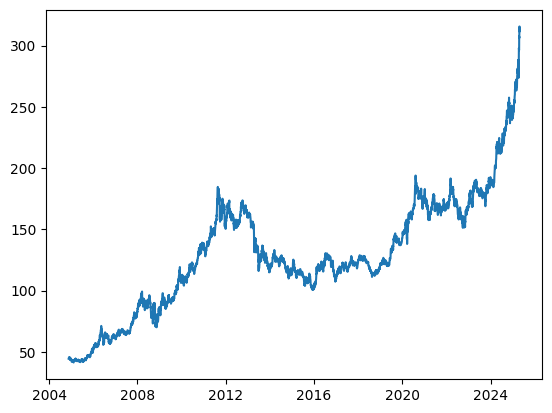

In [28]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Close"])

In [ ]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[["Close"]].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x.flatten())  # flatten to 1D array of n values
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)  # shape (num_samples, n)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = X[:, i]  # each column is Close value at t-n+i

    ret_df["Target"] = Y

    return ret_df

In [30]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,44.380001,44.779999,44.950001,44.750000
1,2004-11-24,44.779999,44.950001,44.750000,45.049999
2,2004-11-26,44.950001,44.750000,45.049999,45.290001
3,2004-11-29,44.750000,45.049999,45.290001,45.400002
4,2004-11-30,45.049999,45.290001,45.400002,45.119999
...,...,...,...,...,...
5130,2025-04-15,292.350006,297.929993,296.230011,297.779999
5131,2025-04-16,297.929993,296.230011,297.779999,307.470001
5132,2025-04-17,296.230011,297.779999,307.470001,306.119995
5133,2025-04-21,297.779999,307.470001,306.119995,315.589996


In [31]:
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


In [32]:
# date, Input -> X, output -> Y
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    # getting the dates
    dates = df_as_np[:, 0]

    # we want the target window columns only and not the last one
    middle_matrix = df_as_np[:, 1:-1]
    # we need to reshape this
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    # ouput vector
    Y = df_as_np[:, -1]

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((5135,), (5135, 3, 1), (5135,))

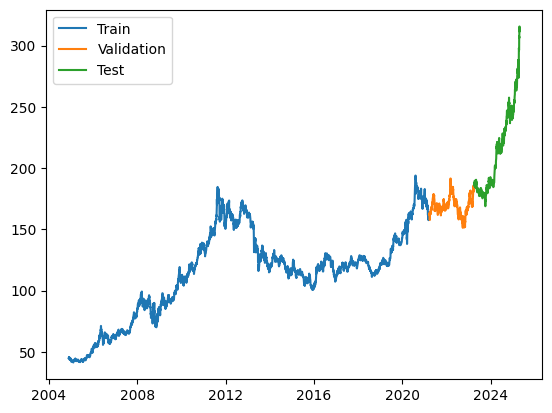

In [33]:
# training part
q_80 = int(len(dates) * 0.8)

# validation part
q_90 = int(len(dates) * 0.9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 1)),  # window size = 3, feature = 1
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11918.9336 - mean_absolute_error: 100.9826 - val_loss: 2360.1191 - val_mean_absolute_error: 48.0933
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 320.0886 - mean_absolute_error: 10.7451 - val_loss: 32.9224 - val_mean_absolute_error: 4.6600
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 5.2567 - mean_absolute_error: 1.4692 - val_loss: 7.8349 - val_mean_absolute_error: 2.1516
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - loss: 3.0862 - mean_absolute_error: 1.1830 - val_loss: 5.9634 - val_mean_absolute_error: 1.9859
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 2.4890 - mean_absolute_error: 1.1024 - val_loss: 4.5040 - val_mean_absolute_error: 1.6904
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 2.8211 - mean_absolute_error: 1.2001 - val_loss: 3.2350 - val_mean_absolute_error: 1.3387
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - loss: 2.3179 

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


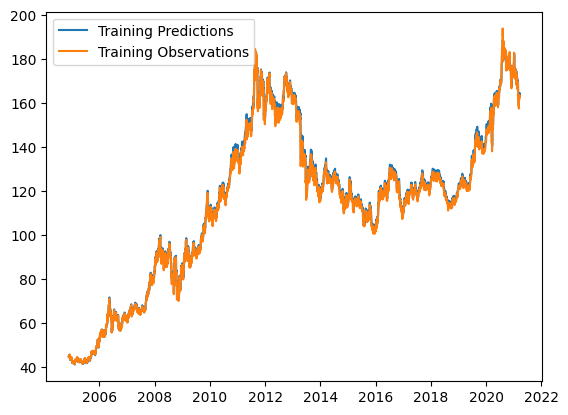

In [35]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step


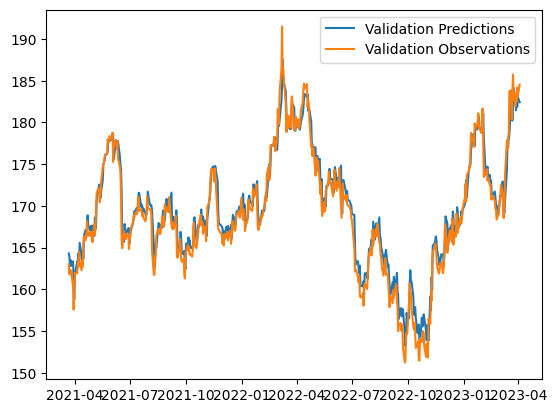

In [36]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step


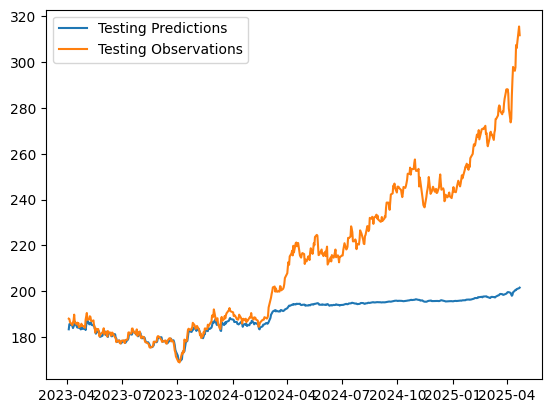

In [37]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])

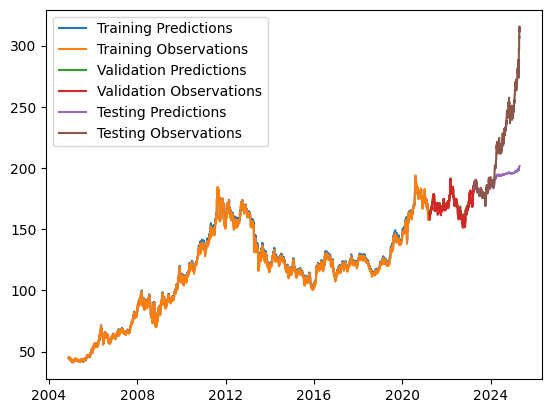

In [38]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [39]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━

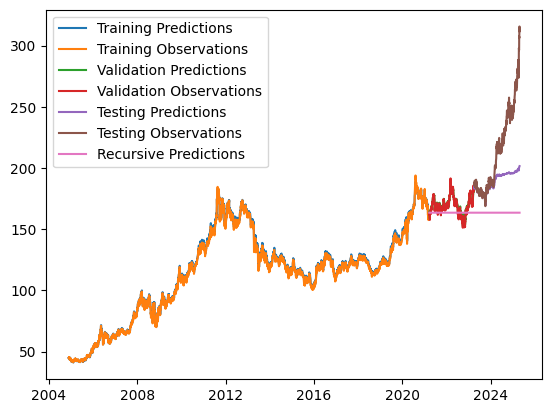

In [40]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)